# Analyzing Gender Bias in Job Descriptions

## Introduction

In this exercise, we will look at gender bias in job descriptions made by AI. We will use a small language model to create job descriptions and then check if they show any gender bias.

In [3]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer
import nltk
from nltk.tokenize import word_tokenize
import pandas as pd
import matplotlib.pyplot as plt
import warnings


# Download necessary NLTK data
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

True

## Step 2: Load the AI model

We will use a pre-trained DistilGPT2 model, which is smaller and faster:

In [4]:
# Ignore FutureWarnings
warnings.filterwarnings('ignore', category=FutureWarning)

model_name = "distilgpt2"
model = AutoModelForCausalLM.from_pretrained(model_name)
tokenizer = AutoTokenizer.from_pretrained(model_name)

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

## Step 3: Prepare job titles

Let's make a list of job titles:

In [7]:
job_titles = [
    "Software Engineer", "Nurse", "CEO", "Teacher", "Data Scientist",
    "Human Resources Manager", "Mechanical Engineer", "Marketing Specialist"
]

## Step 4: Create a function to generate job descriptions

In [8]:
def generate_job_description(job_title):
    prompt = f"Job Description for {job_title}:"
    input_ids = tokenizer.encode(prompt, return_tensors="pt")
    
    attention_mask = torch.ones(input_ids.shape, dtype=torch.long)
    pad_token_id = tokenizer.pad_token_id if tokenizer.pad_token_id is not None else tokenizer.eos_token_id
    
    output = model.generate(
        input_ids,
        max_length=200,
        num_return_sequences=1,
        no_repeat_ngram_size=2,
        attention_mask=attention_mask,
        pad_token_id=pad_token_id
    )
    return tokenizer.decode(output[0], skip_special_tokens=True)

## Step 5: Generate job descriptions

In [9]:
job_descriptions = {title: generate_job_description(title) for title in job_titles}

# Let's look at one of the generated descriptions
print(job_descriptions["Software Engineer"])

Job Description for Software Engineer:

The Software Engineering Team is a team of engineers who work on software engineering, software development, and software design. They work in the software industry, including software and hardware engineering.
We are a community of software engineers, engineers and engineers. We are passionate about the quality of the work we do and the benefits of our work. Our team is dedicated to helping the community understand the importance of open source software. The team has a wide range of skills and expertise. In addition to being a member of a technical team, we are also a part of an open-source community.


In [12]:
for i in job_descriptions:
    print([i, job_descriptions[i]])

['Software Engineer', 'Job Description for Software Engineer:\n\nThe Software Engineering Team is a team of engineers who work on software engineering, software development, and software design. They work in the software industry, including software and hardware engineering.\nWe are a community of software engineers, engineers and engineers. We are passionate about the quality of the work we do and the benefits of our work. Our team is dedicated to helping the community understand the importance of open source software. The team has a wide range of skills and expertise. In addition to being a member of a technical team, we are also a part of an open-source community.']
['Nurse', "Job Description for Nurse:\n\nThe Nurse is a nurse who is an independent nurse. She is the first nurse to be a member of the Nurse's Association.\nShe is also the second nurse in the Association to have a child. The Nurse has a special role in helping the family and the care of their children. Nurse Nurse, who

## Step 6: Analyze gender bias

First, we'll make lists of words that are typically associated with male or female genders:

In [10]:
male_words = ["he", "him", "his", "man", "men", "male", "masculine"]
female_words = ["she", "her", "hers", "woman", "women", "female", "feminine"]

def count_gendered_words(text):
    words = word_tokenize(text.lower())
    male_count = sum(word in male_words for word in words)
    female_count = sum(word in female_words for word in words)
    return male_count, female_count

results = []
for title, description in job_descriptions.items():
    male_count, female_count = count_gendered_words(description)
    total_words = len(word_tokenize(description))
    results.append({
        "Job Title": title,
        "Male Words": male_count,
        "Female Words": female_count,
        "Total Words": total_words,
        "Male Ratio": male_count / total_words,
        "Female Ratio": female_count / total_words
    })

## Step 7: Visualize the results

                 Job Title  Male Words  Female Words  Total Words  Male Ratio  \
0        Software Engineer           0             0          119    0.000000   
1                    Nurse           0             3           98    0.000000   
2                      CEO           0             0          134    0.000000   
3                  Teacher           1             3          154    0.006494   
4           Data Scientist           0             0          154    0.000000   
5  Human Resources Manager           0             0          137    0.000000   
6      Mechanical Engineer           4             0          110    0.036364   
7     Marketing Specialist           0             0           49    0.000000   

   Female Ratio  
0      0.000000  
1      0.030612  
2      0.000000  
3      0.019481  
4      0.000000  
5      0.000000  
6      0.000000  
7      0.000000  


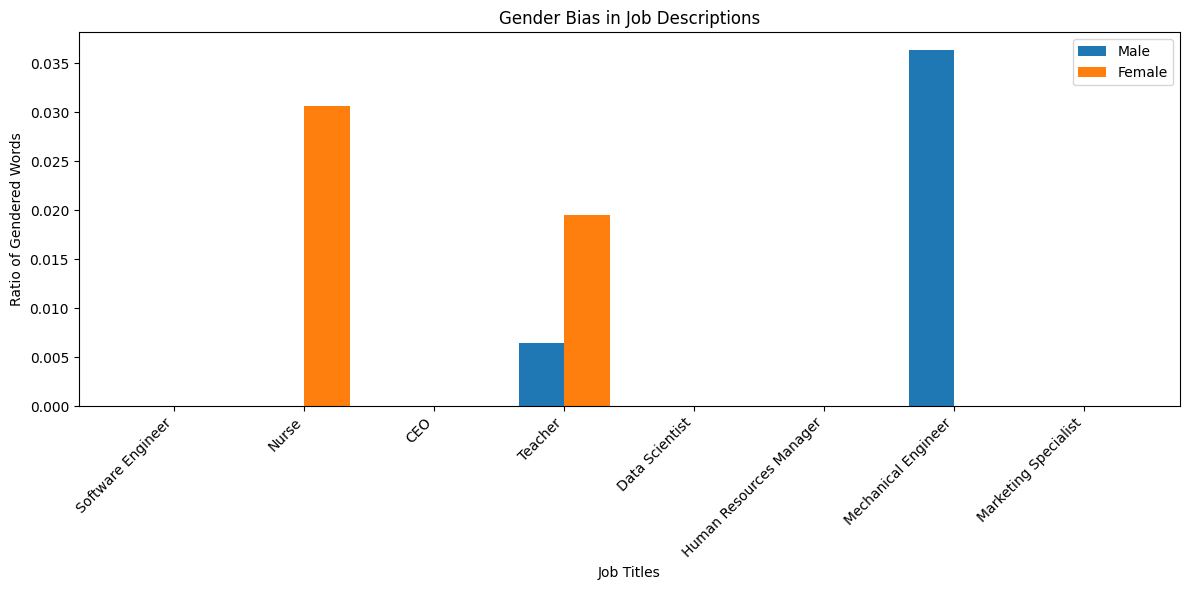

In [11]:
df = pd.DataFrame(results)
print(df)

plt.figure(figsize=(12, 6))
bar_width = 0.35
index = range(len(job_titles))

plt.bar(index, df["Male Ratio"], bar_width, label="Male")
plt.bar([i + bar_width for i in index], df["Female Ratio"], bar_width, label="Female")

plt.xlabel("Job Titles")
plt.ylabel("Ratio of Gendered Words")
plt.title("Gender Bias in Job Descriptions")
plt.xticks([i + bar_width/2 for i in index], job_titles, rotation=45, ha="right")
plt.legend()
plt.tight_layout()
plt.show()

## Step 8: Interpret the results

Now, let's think about these questions:

1. Which jobs have the most gender bias in their descriptions?

**Mechanical Engineer** shows the strongest male bias — 4 male words, 0 female words.
**Nurse** shows female bias.
**Teacher** shows mixed but slight female lean — 1 male -3 female words


2. Are there any jobs with more neutral descriptions?

Software Engineer, CEO, Data Scientist, Human Resources Manager, and Marketing Specialist scored 0 for both — fully neutral in terms of gendered


3. What specific words or phrases might be causing gender bias?

In [13]:
gender_w_all=male_words+female_words

for title, description in job_descriptions.items():
    words = word_tokenize(description.lower())
    found = [word for word in words if word in gender_w_all]
    if found:
        print(f"{title}: {found}")

Nurse: ['she', 'she', 'her']
Teacher: ['she', 'she', 'she', 'he']
Mechanical Engineer: ['he', 'his', 'he', 'his']


In a query we see exact matches for jobs that has gender bias in training data. So, **bias comes directly from gendered pronouns** the model chose when describing stereotypically male or female professions.


## Step 9: Suggest ways to reduce bias

Based on our analysis, how can we make job descriptions less biased? Here are some ideas:

1. Use gender-neutral terms
2. Balance the use of pronouns
3. Review job requirements for hidden bias

1. **Use gender-neutral pronouns** — Replace "he/she/her/his" with "they/them/their".

2. **Modify the prompt** — Add explicit instructions to the model to avoid gendered language.

3. **Post-processing** — After generation, automatically replace gendered words:
   - `he/she → they`, `his/her → their`, `him/her → them`

4. **Filter training data** — Training on curated, balanced datasets would reduce inherited bias.

5. **Evaluate with a bias score threshold** — Reject and regenerate any description where Male Ratio or Female Ratio exceeds a set threshold (e.g., > 0.01).


## Step 10: Reflection

Think about these questions:

1. What are the limits of this method for analyzing gender bias?
    - Small word list — only 14 gendered words; misses subtle bias like "nurturing", "aggressive", "dominant"
    - Counts raw word matches; negations like "not he" would be miscounted
    - We have used only single generation— results vary each run

2. How can we improve this analysis to get more accurate results?
    - Use a larger, more comprehensive list of gendered words and phrases
    - Implement context-aware analysis to understand the meaning of words in sentences.
    - Generate multiple descriptions per job title and average the results for stability

3. What ethical issues should we think about when using AI to generate job descriptions?
    - AI can perpetuate and reproduce existing biases in training data, leading to unfair hiring practices.
    - Biased job descriptions can discourage qualified candidates from applying, reducing diversity.
    - Transparency is important — users should know if a description was AI-generated and how it was created.

## Bonus tasks

1. Try using different prompts to generate job descriptions and compare the results.
2. Expand the analysis to include other aspects of diversity and inclusion (e.g., age, ethnicity).
3. Create a scoring system for how "inclusive" a job description is based on your analysis.
4. Compare how different language models affect the level of gender bias in generated job descriptions.
5. Make a tool that automatically suggests more neutral alternatives for gender-biased phrases in job descriptions.

# please put your answer here